# Price Pattern Algorithm in Python for Trading

Identifying **local tops and bottoms** is a fundamental task in systematic trading. Detecting these turning points allows traders to:

- Define trend structure (higher highs, lower lows)
- Build breakout or mean-reversion strategies
- Construct support and resistance levels
- Detect chart patterns algorithmically

Below are three widely used approaches for identifying price turning points.

---

#### 1️⃣ Rolling Window Method

##### Concept  
A point is considered a local top (or bottom) if it is the maximum (or minimum) within a fixed lookback window.

For a window size \( n \):

A local top at time \( t \) satisfies:

$$
P_t = \max(P_{t-n}, \dots, P_t, \dots, P_{t+n})
$$

A local bottom satisfies:

$$
P_t = \min(P_{t-n}, \dots, P_t, \dots, P_{t+n})
$$

##### Characteristics
- Simple and fast
- Sensitive to window size
- May generate noise in choppy markets

##### Best For
Short-term swing detection and structured backtesting.

---

#### 2️⃣ Directional Change (DC)

##### Concept  
Instead of using fixed time windows, the Directional Change method identifies turning points when price reverses by more than a predefined threshold \( \theta \) (e.g., 2%).

A new top is confirmed when price falls by more than:

$$
\theta \times P_{\text{extreme}}
$$

Similarly, a bottom is confirmed when price rises above the threshold.

##### Characteristics
- Event-driven (not time-driven)
- Adapts to volatility
- Reduces noise compared to rolling windows

##### Best For
Volatility-aware systems and regime detection.

---

#### 3️⃣ Perceptually Important Points (PIP)

##### Concept  
PIP selects key points that best represent the overall shape of a price series. It iteratively selects points that maximize distance from line segments connecting previously selected points.

The distance metric is typically:

- Euclidean distance
- Perpendicular distance to line segment

##### Characteristics
- Captures structural shape
- Reduces dimensionality
- Useful for pattern recognition (triangles, head & shoulders, etc.)

##### Best For
Chart pattern detection and machine learning feature engineering.

Let us import the necessary libraries

In [1]:
import numpy as np
import scipy
import scipy.signal
import pandas as pd
import os
import datetime
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Rolling Window Algorithm

This algorithm looks at a point (red) on a chart and determines if it is a local top by comparing it with its two neighboring points (white)

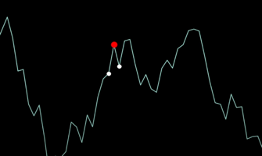

The spacing or differential on the x-axis (understood as a snapshot in a timeseries), is known as the order. To understand it further, consider the following chart and contrast it with the one on top. The above chart is of order 1, since we are comparing the neighboring points with a difference of 1, whereas the bottom chart is a comparison made on order 2.

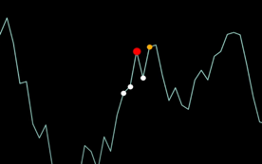


**Code for Rolling Window Algorithm**

In [2]:
# Checks if there is a local top detected at the current index
def rw_top(data: np.array, curr_index: int, order: int):
  if curr_index < order * 2 + 1:
    return False
  top = True
  k = curr_index - order
  v = data[k]
  for i in range(1, order + 1):
    if data[k+i] > v or data[k-i] > v:
      top = False
      break
  return top


def rw_bottom(data: np.array, curr_index: int, order: int):
  if curr_index < order * 2 + 1:
    return False
  bottom = True
  k = curr_index - order
  v = data[k]
  for i in range(1, order + 1):
    if data[k+i] < v or data[k-i] < v:
      bottom = False
      break
  return bottom


def rw_extremes(data: np.array, order: int):
  """
  Find the local extrema in the data.
  :param data: The data to find the extrema in.
  :param order: The order of the extrema.
  :return: A list of tuples containing the index and value of the extrema.
  """
  tops = []
  bottoms = []
  for i in range(len(data)):
    if rw_top(data, i, order):
      # top[0] = confirmation index
      # top[1] = index of top
      # top[2] = price of top
      top = [i, i - order, data[i - order]]
      tops.append(top)
      
    if rw_bottom(data, i, order):
      # bottom[0] = confirmation index
      # bottom[1] = index of bottom
      # bottom[2] = price of bottom
      bottom = [i, i - order, data[i - order]]
      bottoms.append(bottom)
      
  return tops, bottoms

In [3]:
"""
Usage Example:
  data -> refers to a pandas DataFrame containing stock price data

arr = data['close'].to_numpy() # assuming data is a pandas DataFrame of a stock price
bottoms = scipy.signal.argrelextrema(arr, np.less, order=3)
tops = scipy.signal.argrelextrema(arr, np.greater, order=3)
"""

"\nUsage Example:\n  data -> refers to a pandas DataFrame containing stock price data\n\narr = data['close'].to_numpy() # assuming data is a pandas DataFrame of a stock price\nbottoms = scipy.signal.argrelextrema(arr, np.less, order=3)\ntops = scipy.signal.argrelextrema(arr, np.greater, order=3)\n"

### Directional Change

This algorithm identifies tops and bottom for a stock price when it has retraced by a given amount from its most recent highs or lows. Note that this algorithm will always produce alternating tops and bottoms

Let the yellow line be our confirmation line, and when we see price action closing at a set percentage (e.g 3% change) from the yellow line, we can confirm our bottom. 

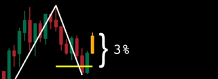

Then the algorithm will continue to monitor the change in price when it closes 3% below the previous set high. The new blue line is our confirmation level, which is 3% below the blue line that we have confirmed.

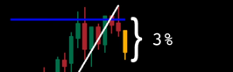



**Code for Directional Change Algorithm**

In [4]:
def directional_change(close: np.array, high: np.array, low: np.array, sigma: float):
  up_zig = True # Last extreme is a bottom, Next is a top
  tmp_max = high[0]
  tmp_min = low[0]
  tmp_max_index = 0
  tmp_min_index = 0
  
  tops = []
  bottoms = []
  
  for i in range(len(close)):
    if up_zig: # Last extreme is a bottom
      if high[i] > tmp_max:
        # Update new high
        tmp_max = high[i]
        tmp_max_index = i
      elif close[i] < tmp_max - tmp_max * sigma:
        # Price retraced by sigma %, top confirmed, record it
        # top[0] = confirmation index
        # top[1] = index of top
        # top[2] = price of top
        top = [i, tmp_max_index, tmp_max]
        tops.append(top)
        
        # setup for next bottom
        up_zig = False
        tmp_min = low[i]
        tmp_min_index = i
    else: # last extreme is a top
      if low[i] < tmp_min:
        # Update new low
        tmp_min = low[i]
        tmp_min_index = i
      elif close[i] > tmp_min + tmp_min * sigma:
        # Price retraced by sigma %, bottom confirmed, record it
        # bottom[0] = confirmation index
        # bottom[1] = index of bottom
        # bottom[2] = price of bottom
        bottom = [i, tmp_min_index, tmp_min]
        bottoms.append(bottom)
        
        # setup for next top
        up_zig = True
        tmp_max = high[i]
        tmp_max_index = i
        
  return tops, bottoms

### Perceptually Important Points

For this algorithm, it is given a section of price data, and from there, it will determine the n most important points. For instance, consider the chart, below, if n = 7, it will identify 7 most important points on the chart.

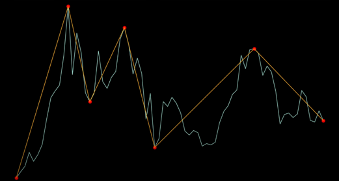

See the steps below

| Step | Algorithm                                                                 | Visual                                      |
|------|---------------------------------------------------------------------------|---------------------------------------------|
| 1    | First, 2 points will be drawn to indicate the start and end points from the given section. A line is then drawn to connect the 2 points together as shown | 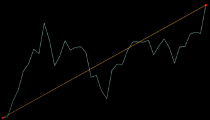|
| 2    | Using a for loop, we will find the vertical distance of each point from the line | 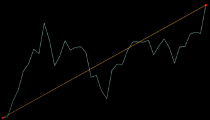|
| 3    | The point with the maximum distance will be selected as the next point.   | 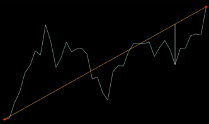|
| 4    | We will then loop through the points again, derive the distance between each price point from the given line, and select the next point with the maximum distance from the given line(s) | 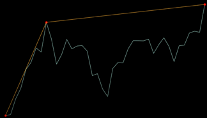|

**Code for Perceptuall Important Points Algorithm**

In [5]:
def find_pips(data: np.array, n_pips: int, dist_measure: int):
  # dist measure
  # 1 = euclidean distance
  # 2 = Perpendicular distance
  # 3 = Vertical distance
  
  pips_x = [0, len(data) - 1]  # index
  pips_y = [data[0], data[-1]] # price
  
  for curr_point in range(2, n_pips):
    md = 0.0 # Max distance
    md_index = -1 # Max distance index
    insert_index = -1 # Insert index
    
    for k in range(0, curr_point - 1):
      # left adjacent, right adjacent indices
      left_adj = k
      right_adj = k + 1
      
      time_diff = pips_x[right_adj] - pips_x[left_adj]
      price_diff = pips_y[right_adj] - pips_y[left_adj]
      slope = price_diff / time_diff
      intercept = pips_y[left_adj] - slope * pips_x[left_adj]
      
      for i in range(pips_x[left_adj] + 1, pips_x[right_adj]):
        d = 0.0 # distance
        if dist_measure == 1:
          # Euclidean distance
          d = ((pips_x[left_adj] - i) ** 2 + (pips_y[left_adj] - data[i]) ** 2) ** 0.5
          d += ((pips_x[right_adj] - i) ** 2 + (pips_y[right_adj] - data[i]) ** 2) ** 0.5
        elif dist_measure == 2:
          # Perpendicular distance
          d = abs((slope * i + intercept) - data[i]) / (slope ** 2 + 1) ** 0.5
        elif dist_measure == 3:
          # Vertical distance
          d = abs((slope * i + intercept) - data[i])
          
        if d > md:
          md = d
          md_index = i
          insert_index = right_adj
    # Insert the new point
    pips_x.insert(insert_index, md_index)
    pips_y.insert(insert_index, data[md_index])
  
  return pips_x, pips_y
        

**Visualise the algorithms with sample Bitcoin data**

- Download the data from here: https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/BTCUSDT3600.csv
- Download the data from here: https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/BTCUSDT86400.csv

In [ ]:
# Load the data
btc3600 = pd.read_csv('BTCUSDT3600.csv')
btc86400 = pd.read_csv('BTCUSDT86400.csv')

Plot the data for our btc3600 and btc86400

In [7]:
# Convert the date column to datetime
btc3600['date'] = btc3600['date'].astype('datetime64[s]')
btc86400['date'] = btc86400['date'].astype('datetime64[s]')

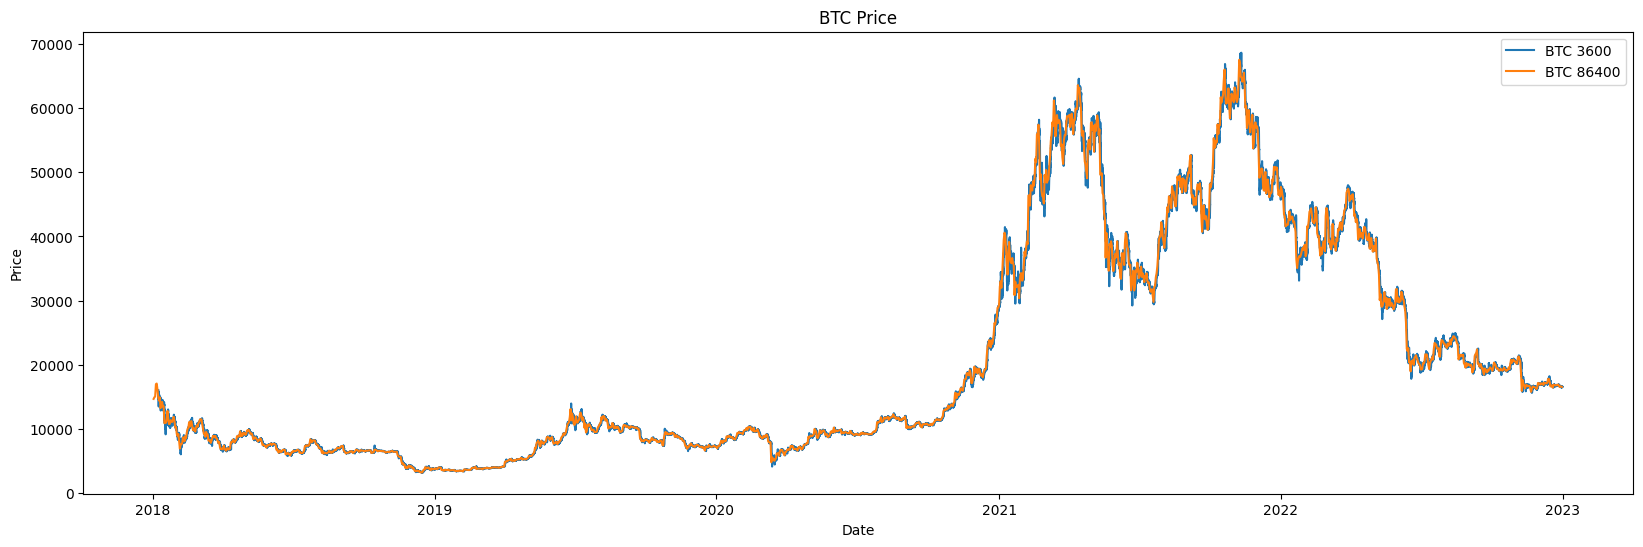

In [8]:
# Stretch the length of the image
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)
plt.plot(btc3600['date'], btc3600['close'], label='BTC 3600')
plt.plot(btc86400['date'], btc86400['close'], label='BTC 86400')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()

*Visualising the Rolling Window Algorithm*

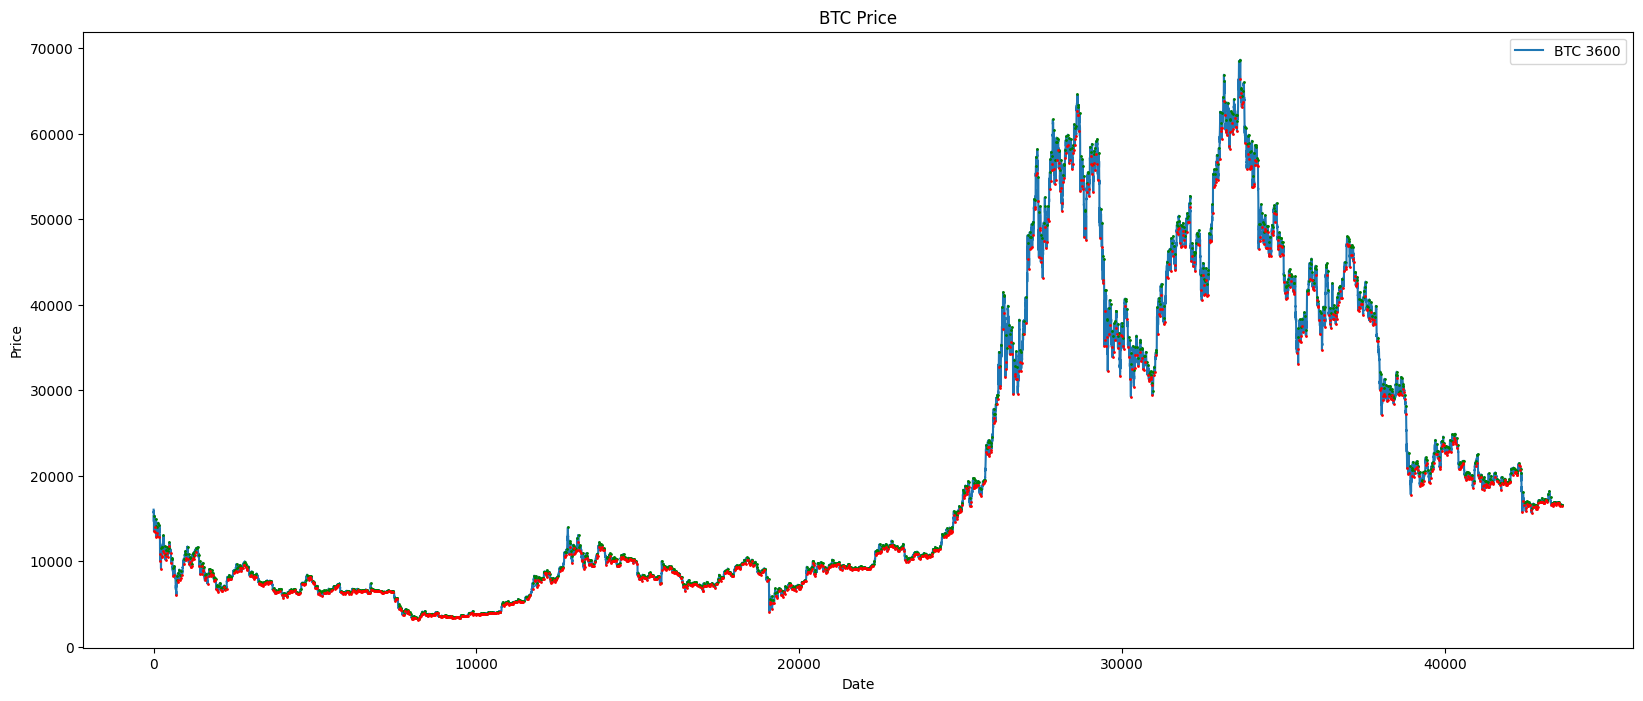

In [9]:
tops, bottoms = rw_extremes(btc3600['close'].to_numpy(), 10)
idx = btc3600.index
fig = plt.figure(figsize=(20, 8))
plt.plot(btc3600['close'], label='BTC 3600')
for top in tops:
  plt.plot(idx[top[1]], top[2], marker='o', color='green', markersize=1)
for bottom in bottoms:
  plt.plot(idx[bottom[1]], bottom[2], marker='o', color='red', markersize=1)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()

*Isolate to a certain period (e.g 2020-01-01 - 2020-06-01)*

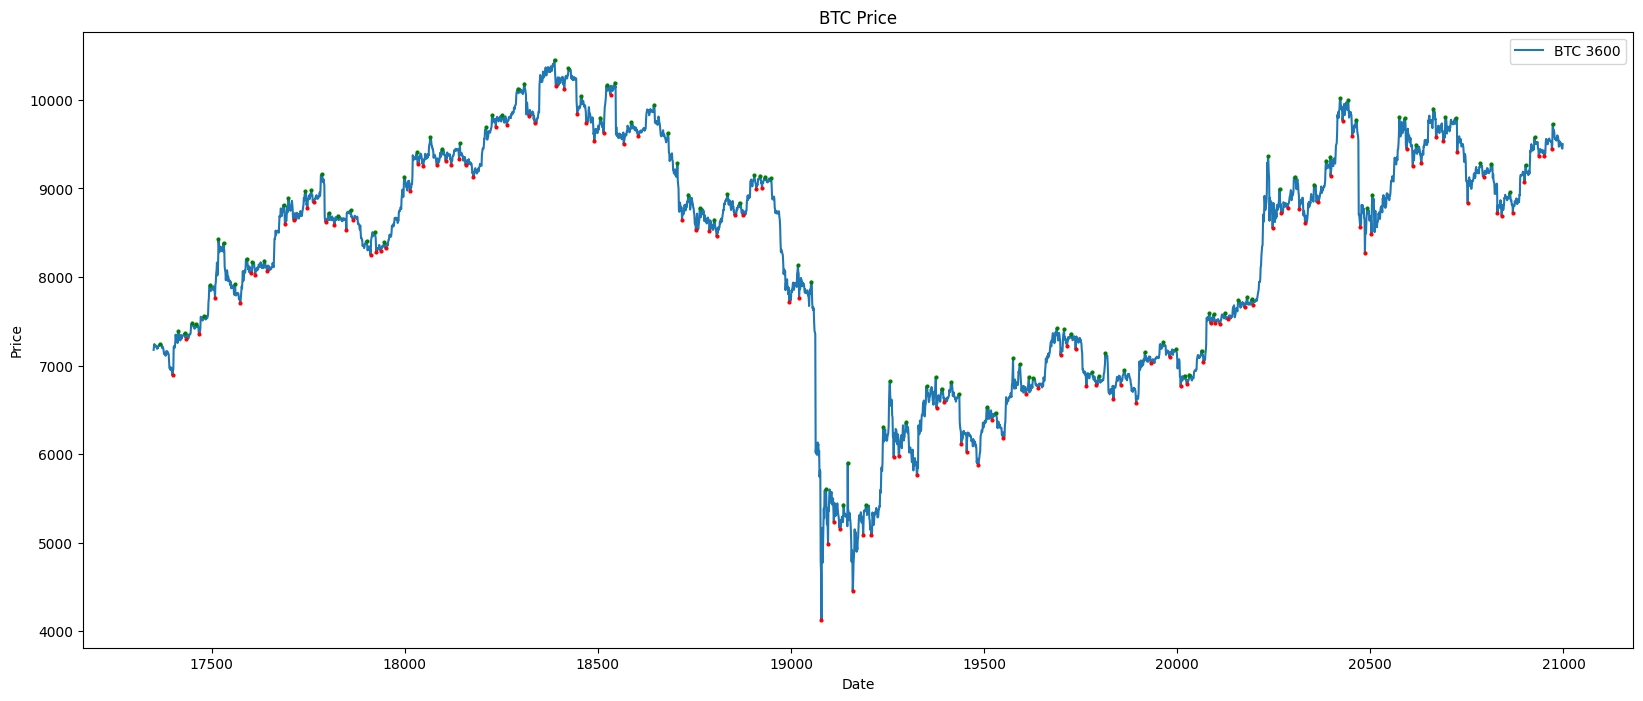

In [10]:
# get data from 2020-01-01 to 2020-12-31
btc3600_range = btc3600[(btc3600['date'] >= '2020-01-01') & (btc3600['date'] <= '2020-06-01')]

tops, bottoms = rw_extremes(btc3600_range['close'].to_numpy(), 10)
idx = btc3600_range.index
fig = plt.figure(figsize=(20, 8))
plt.plot(btc3600_range['close'], label='BTC 3600')
for top in tops:
  plt.plot(idx[top[1]], top[2], marker='o', color='green', markersize=2)
for bottom in bottoms:
  plt.plot(idx[bottom[1]], bottom[2], marker='o', color='red', markersize=2)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()

*Visualising the Directional Change Algorithm*

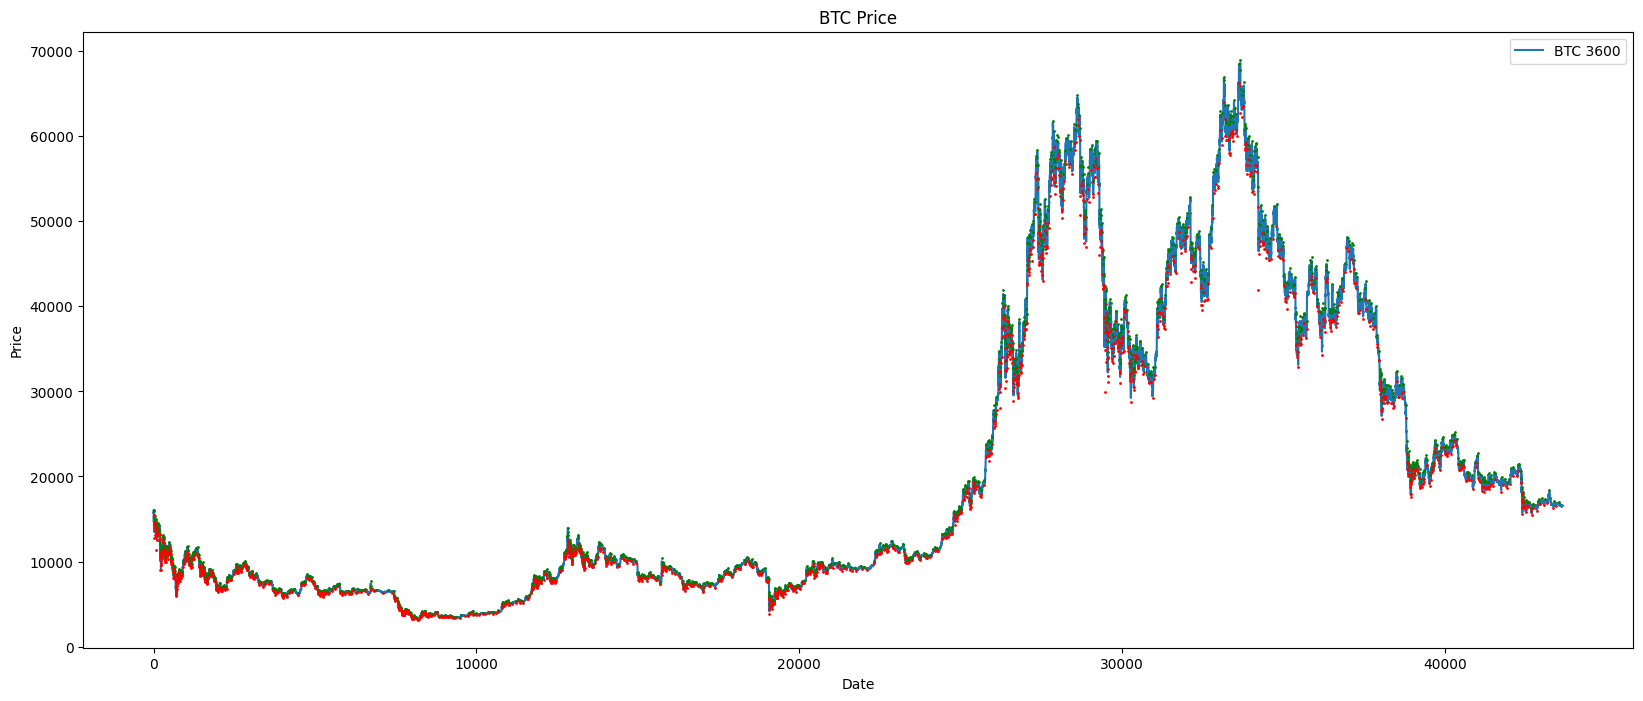

In [11]:
tops, bottoms = directional_change(btc3600['close'].to_numpy(), btc3600['high'].to_numpy(), btc3600['low'].to_numpy(), 0.02)
idx = btc3600.index
fig = plt.figure(figsize=(20, 8))
plt.plot(btc3600['close'], label='BTC 3600')
for top in tops:
  plt.plot(top[1], top[2], marker='o', color='green', markersize=1)
for bottom in bottoms:
  plt.plot(bottom[1], bottom[2], marker='o', color='red', markersize=1)
  
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()

*Isolate to a certain period (e.g 2020-01-01 - 2020-06-01)*

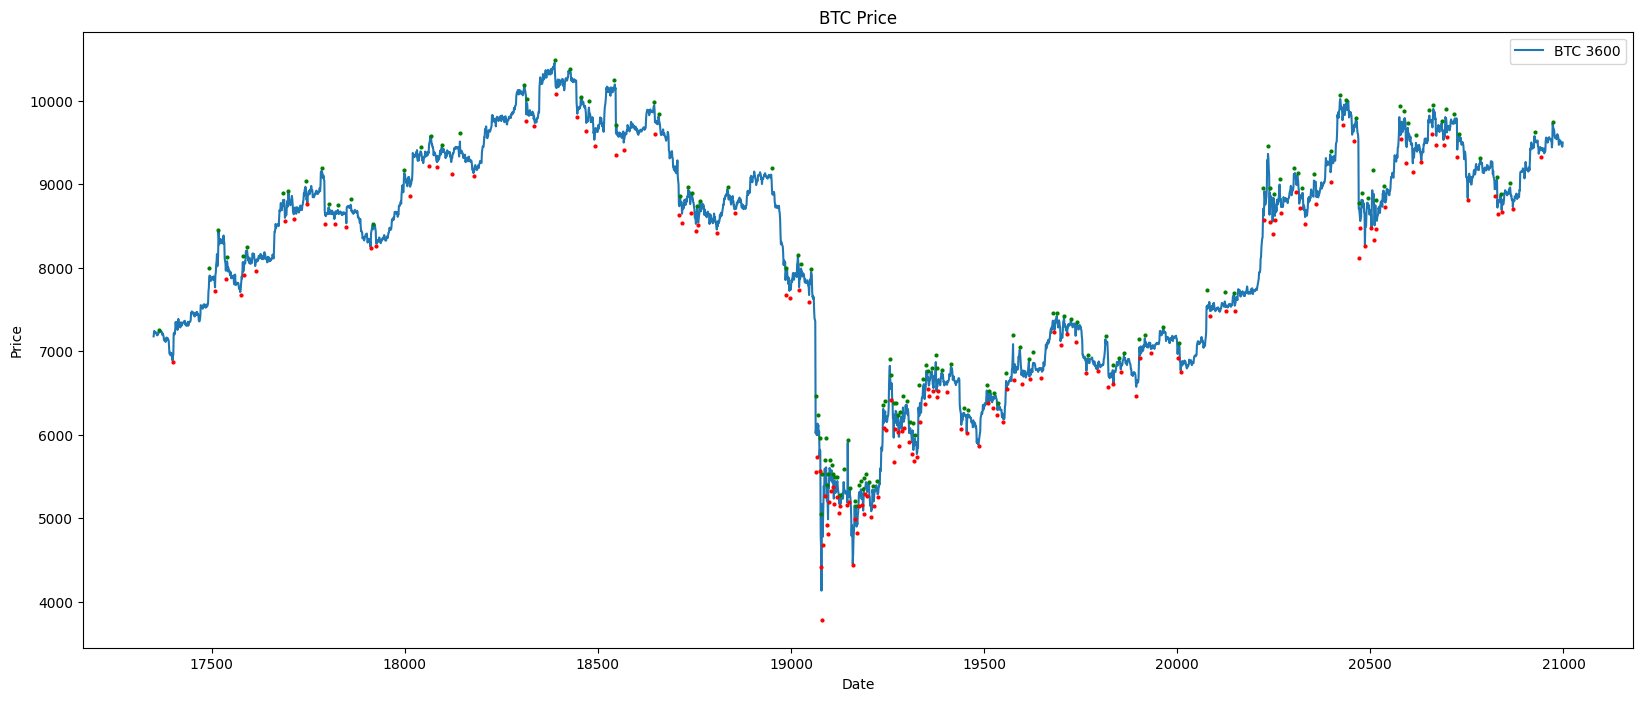

In [12]:
# get data from 2020-01-01 to 2020-12-31
btc3600_range = btc3600[(btc3600['date'] >= '2020-01-01') & (btc3600['date'] <= '2020-06-01')]
idx = btc3600_range.index
tops, bottoms = directional_change(btc3600_range['close'].to_numpy(), btc3600_range['high'].to_numpy(), btc3600_range['low'].to_numpy(), 0.02)
fig = plt.figure(figsize=(20, 8))
plt.plot(btc3600_range['close'], label='BTC 3600')

for top in tops:
  plt.plot(idx[top[1]], top[2], marker='o', color='green', markersize=2)
for bottom in bottoms:
  plt.plot(idx[bottom[1]], bottom[2], marker='o', color='red', markersize=2)
  
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()

*Visualising the Perceptually Important Points Algorithm*

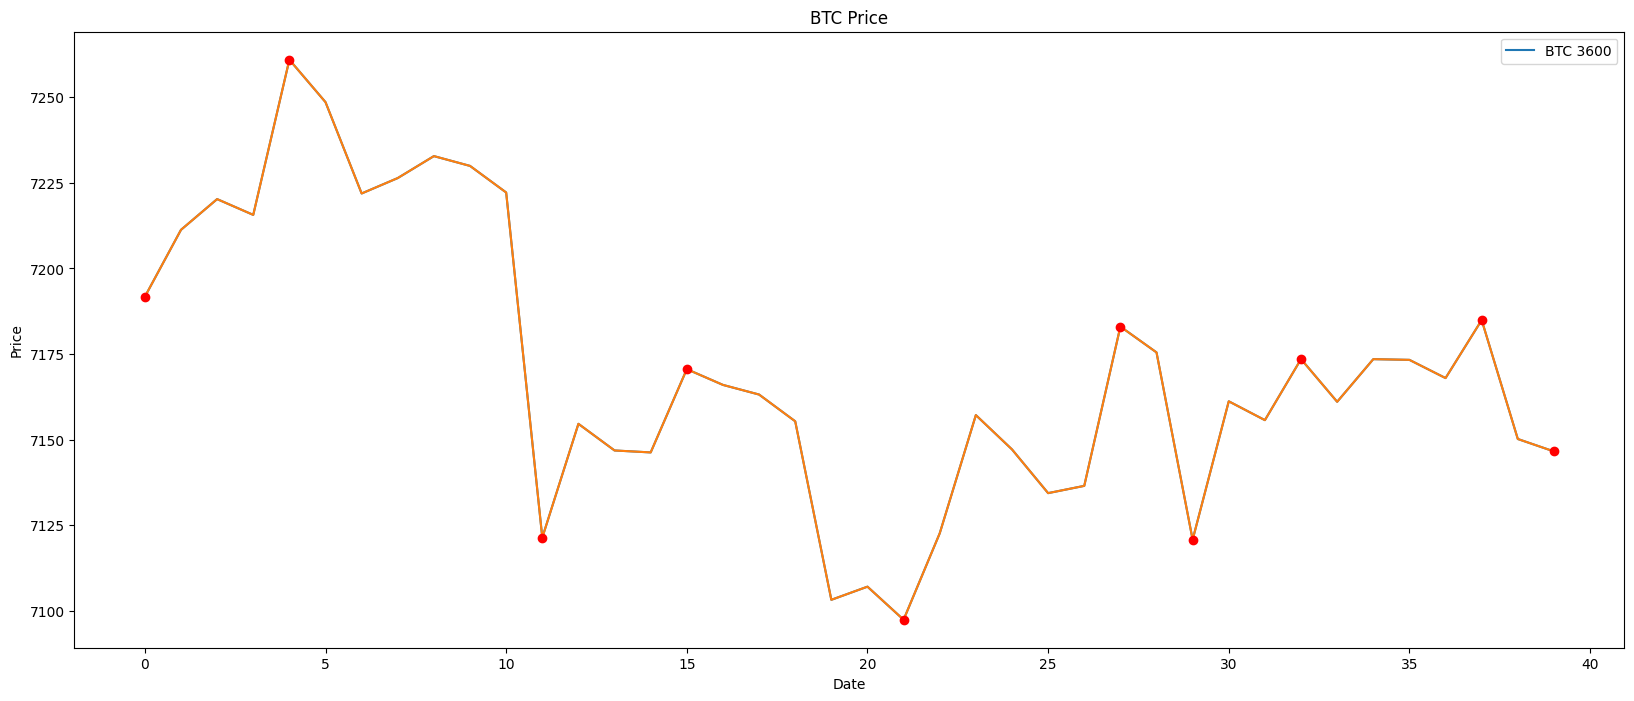

In [13]:
# Change the value of i and p to get a different result
i = 20000
p = 10
x = btc3600['close'].iloc[i-40:i].to_numpy()
pips_x, pips_y = find_pips(x, p, 2)
fig = plt.figure(figsize=(20, 8))
plt.plot(x, label='BTC 3600')

pd.Series(x).plot()
for i in range(p):
  plt.plot(pips_x[i], pips_y[i], marker='o', color='red')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price')
plt.legend()
plt.show()